# Comparative Evaluation: Proposed Model vs. YOLO Base (Zero-Shot)
This notebook evaluates the performance of the model adapted to the egocentric domain (8-class semantic taxonomy) against a generic pre-trained model (YOLOv8s on COCO). 

Mean Average Precision (mAP) metrics are extracted, and confusion matrices are manually generated (via IoU) to avoid library biases and network access issues on the cluster.

In [1]:
import os
import shutil
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision.ops import box_iou
from ultralytics import YOLO
import ultralytics.data.utils as checks
import warnings

warnings.filterwarnings('ignore')

# Disable Ultralytics font checking (prevents Arial.ttf error on offline servers)
checks.check_font = lambda *args, **kwargs: None

# ==========================================
# GLOBAL PATHS (Adjust if necessary)
# ==========================================
DIR_IMAGES_VAL = Path('/nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/data/epic_train_subset/val/images')
DIR_LABELS_VAL = Path('/nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/data/epic_train_subset/val/labels')
YAML_PROPOSED = Path('/nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/data/epic_train_subset/dataset.yaml')

WEIGHTS_PROPOSED = "/nfs/workspace/sebastian.toro/runs/detect/epic_full_epoch7/weights/best.pt"
WEIGHTS_BASE = 'yolov8s.pt'

print("✅ Environment successfully configured.")

mkdir -p failed for path /home/sebastian.toro/.config/matplotlib: [Errno 13] Permission denied: '/home/sebastian.toro'
Matplotlib created a temporary cache directory at /tmp/matplotlib-0w761koi because there was an issue with the default path (/home/sebastian.toro/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


✅ Environment successfully configured.


In [2]:
def generate_confusion_matrix(model, dir_img, dir_lbl, class_map, class_names, title, conf_thresh=0.25, iou_thresh=0.45):
    """Calculates and plots the confusion matrix by matching predictions and Ground Truth via IoU."""
    num_classes = len(class_names)
    matrix = np.zeros((num_classes, num_classes), dtype=np.int32)
    
    for img_path in list(Path(dir_img).glob("*.*")):
        # 1. Read Ground Truth
        lbl_path = Path(dir_lbl) / (img_path.stem + ".txt")
        t_boxes, t_classes = [], []
        if lbl_path.exists():
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts: continue
                    c_id = int(parts[0])
                    if c_id in class_map:
                        xc, yc, w, h = map(float, parts[1:5])
                        t_boxes.append([xc - w/2, yc - h/2, xc + w/2, yc + h/2])
                        t_classes.append(class_map[c_id])
                        
        t_boxes = torch.tensor(t_boxes) if t_boxes else torch.empty((0, 4))
        
        # 2. Read Predictions
        res = model(str(img_path), verbose=False, conf=conf_thresh, classes=list(class_map.keys()))[0]
        p_boxes, p_classes = [], []
        if len(res.boxes) > 0:
            h_img, w_img = res.orig_shape
            for box in res.boxes:
                c_id = int(box.cls[0])
                if c_id in class_map:
                    x1, y1, x2, y2 = box.xyxy[0].tolist()
                    p_boxes.append([x1/w_img, y1/h_img, x2/w_img, y2/h_img])
                    p_classes.append(class_map[c_id])
                    
        p_boxes = torch.tensor(p_boxes) if p_boxes else torch.empty((0, 4))
        
        # 3. Match boxes (IoU)
        matched_t, matched_p = set(), set()
        if len(t_boxes) > 0 and len(p_boxes) > 0:
            ious = box_iou(t_boxes, p_boxes)
            for t_idx, t_cls in enumerate(t_classes):
                valid_preds = torch.where(ious[t_idx] > iou_thresh)[0]
                if len(valid_preds) > 0:
                    p_idx = valid_preds[torch.argmax(ious[t_idx][valid_preds])].item()
                    p_cls = p_classes[p_idx]
                    if p_idx not in matched_p:
                        matrix[t_cls, p_cls] += 1
                        matched_t.add(t_idx); matched_p.add(p_idx)
                        
        # False Negatives and False Positives (Background)
        for t_idx, t_cls in enumerate(t_classes):
            if t_idx not in matched_t: matrix[t_cls, num_classes-1] += 1
        for p_idx, p_cls in enumerate(p_classes):
            if p_idx not in matched_p: matrix[num_classes-1, p_cls] += 1

    # 4. Draw Plot
    row_sums = matrix.sum(axis=1, keepdims=True)
    matrix_norm = np.divide(matrix, row_sums, out=np.zeros_like(matrix, dtype=float), where=row_sums!=0)

    fig, ax = plt.subplots(figsize=(10 if num_classes > 4 else 7, 8 if num_classes > 4 else 6))
    ax.matshow(matrix_norm, cmap='Blues')

    for i in range(num_classes):
        for j in range(num_classes):
            color = "white" if matrix_norm[i, j] > 0.5 else "black"
            ax.text(j, i, f"{matrix_norm[i, j]:.2f}", ha="center", va="center", color=color, fontsize=11)

    ax.set_xticks(np.arange(num_classes)); ax.set_yticks(np.arange(num_classes))
    ax.xaxis.set_ticks_position('bottom')
    ax.set_xticklabels(class_names, rotation=45 if num_classes > 4 else 0, ha='right' if num_classes > 4 else 'center', fontsize=12)
    ax.set_yticklabels(class_names, fontsize=12)
    plt.xlabel("Model Prediction", fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel("Ground Truth", fontsize=12, fontweight='bold', labelpad=10)
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
print("✅ Matrix calculation engine loaded.")

✅ Matrix calculation engine loaded.


---
## 1. PROPOSED MODEL (Fine-Tuned)
Evaluation of the model specifically trained on the EPIC-KITCHENS egocentric domain, using the 8-super-class semantic taxonomy.

### 1.1 mAP Generation (Proposed)

In [3]:
model_proposed = YOLO(WEIGHTS_PROPOSED) 

metrics_proposed = model_proposed.val(
    data=str(YAML_PROPOSED),
    split='val',
    plots=False, 
    project=str(Path.cwd() / "runs_eval"),
    name='proposed_map'
)

print("\n🏆 GLOBAL mAP@50 (Proposed Model):", round(metrics_proposed.box.map50, 4))
print("-" * 40)
for i, class_idx in enumerate(metrics_proposed.ap_class_index):
    print(f"- {metrics_proposed.names[class_idx]}: AP@50 = {metrics_proposed.box.ap50[i]:.4f}")

Ultralytics 8.4.21 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX 4500 Ada Generation, 24088MiB)
Model summary (fused): 73 layers, 11,128,680 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 201.4±40.8 MB/s, size: 204.2 KB)
val: Scanning /nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/data/epic_train_subset/val/labels.cache... 774 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 774/774 104.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 13.9it/s 3.5s0.1s
                   all        774        859      0.719      0.675      0.707       0.37
                 bread        100        111      0.802      0.764      0.842      0.526
                 knife         96        103       0.65       0.45       0.46      0.174
                cheese         88        104      0.704      0.683      0.659      0.315
                  meat         97  

### 1.2 Confusion Matrix (Proposed)

Calculating matrix for the proposed model...


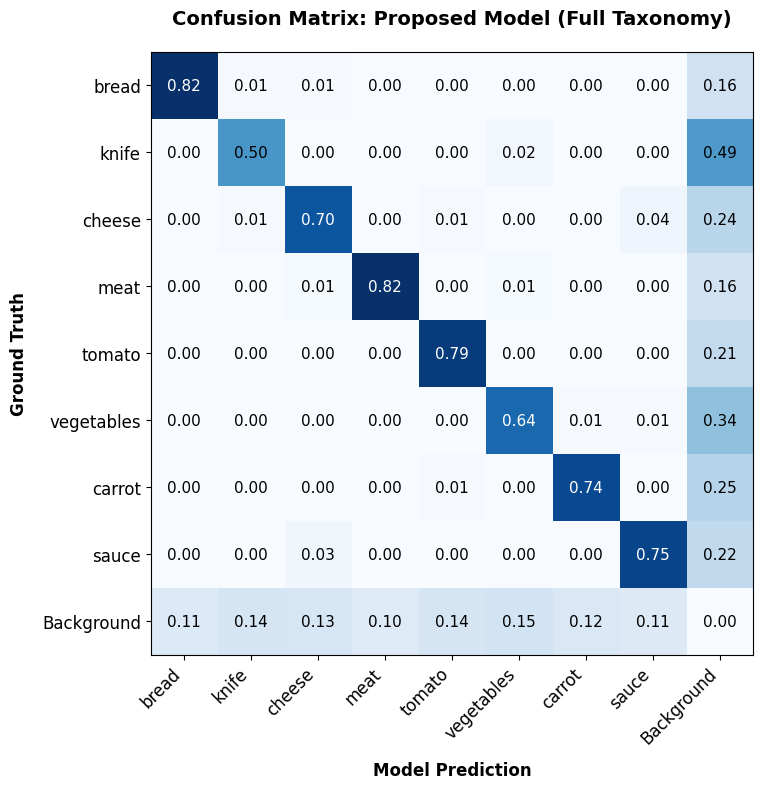

In [4]:
print("Calculating matrix for the proposed model...")

# Direct mapping: Class ID to matrix position (0 to 7)
map_proposed = {i: i for i in range(8)}
names_proposed = ['bread', 'knife', 'cheese', 'meat', 'tomato', 'vegetables', 'carrot', 'sauce', 'Background']

generate_confusion_matrix(
    model=model_proposed,
    dir_img=DIR_IMAGES_VAL,
    dir_lbl=DIR_LABELS_VAL,
    class_map=map_proposed,
    class_names=names_proposed,
    title="Confusion Matrix: Proposed Model (Full Taxonomy)"
)

---
## 2. BASELINE MODEL (Zero-Shot)
Evaluation of the standard pre-trained model on COCO (80 classes). For a fair comparison, we limit the analysis to the only two classes that overlap with our dataset: **Knife (ID 43)** and **Carrot (ID 51)**.

### 2.1 Data Preparation (Translation to COCO Format)
We create a temporary environment that bypasses the validator by translating our clinical labels into generic COCO IDs.

In [5]:
TEMP_DATASET = Path.cwd() / 'temp_eval_coco'
TEMP_IMAGES = TEMP_DATASET / 'images' / 'val'
TEMP_LABELS = TEMP_DATASET / 'labels' / 'val'

if TEMP_DATASET.exists(): shutil.rmtree(TEMP_DATASET)
TEMP_IMAGES.mkdir(parents=True, exist_ok=True)
TEMP_LABELS.mkdir(parents=True, exist_ok=True)

print("Translating dataset to COCO format...")

# Link images
for img_file in DIR_IMAGES_VAL.glob('*.*'):
    try: (TEMP_IMAGES / img_file.name).symlink_to(img_file)
    except OSError: shutil.copy(img_file, TEMP_IMAGES / img_file.name)

# Translate IDs
for label_file in DIR_LABELS_VAL.glob('*.txt'):
    with open(label_file, 'r') as f: lines = f.readlines()
    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if not parts: continue
        c_id = int(parts[0])
        if c_id == 1: # Knife
            parts[0] = '43'; new_lines.append(' '.join(parts))
        elif c_id == 6: # Carrot
            parts[0] = '51'; new_lines.append(' '.join(parts))
    with open(TEMP_LABELS / label_file.name, 'w') as f:
        f.write('\n'.join(new_lines))

# Create dummy YAML
yaml_dict = {
    'path': str(TEMP_DATASET), 'train': 'images/val', 'val': 'images/val',
    'names': {i: f'class_{i}' for i in range(80)}
}
yaml_dict['names'][43] = 'knife_base'
yaml_dict['names'][51] = 'carrot_base'
YAML_BASE = TEMP_DATASET / 'eval_coco.yaml'

with open(YAML_BASE, 'w') as f: yaml.dump(yaml_dict, f)
print("✅ Temporary Baseline dataset prepared.")

Translating dataset to COCO format...
✅ Temporary Baseline dataset prepared.


### 2.2 mAP Generation (Baseline)

In [6]:
model_base = YOLO(WEIGHTS_BASE) 

metrics_base = model_base.val(
    data=str(YAML_BASE),
    split='val',
    plots=False, 
    project=str(Path.cwd() / "runs_eval"),
    name='baseline_map',
    classes=[43, 51] # Restrict to knife and carrot
)

print("\n⚠️ GLOBAL mAP@50 (Baseline):", round(metrics_base.box.map50, 4))
print("-" * 40)
for i, class_idx in enumerate(metrics_base.ap_class_index):
    print(f"- {yaml_dict['names'][class_idx]}: AP@50 = {metrics_base.box.ap50[i]:.4f}")

Ultralytics 8.4.21 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX 4500 Ada Generation, 24088MiB)
YOLOv8s summary (fused): 72 layers, 11,156,544 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1412.6±330.5 MB/s, size: 207.4 KB)
val: Scanning /nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/temp_eval_coco/labels/val... 774 images, 579 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 774/774 1.4Kit/s 0.5s0.0ss
val: New cache created: /nfs/workspace/sebastian.toro/EPIC-KITCHENS/Ego-Kitchen-YOLO/notebooks/temp_eval_coco/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 15.7it/s 3.1s0.1s
                   all        774        211     0.0964      0.199     0.0602     0.0211
                 knife         96        103     0.0715      0.184     0.0605     0.0238
                carrot         99        108      0.121      0.213     0.0599     0.0184
Sp

### 2.3 Confusion Matrix (Baseline)

Calculating matrix for Baseline Model (Zero-Shot)...


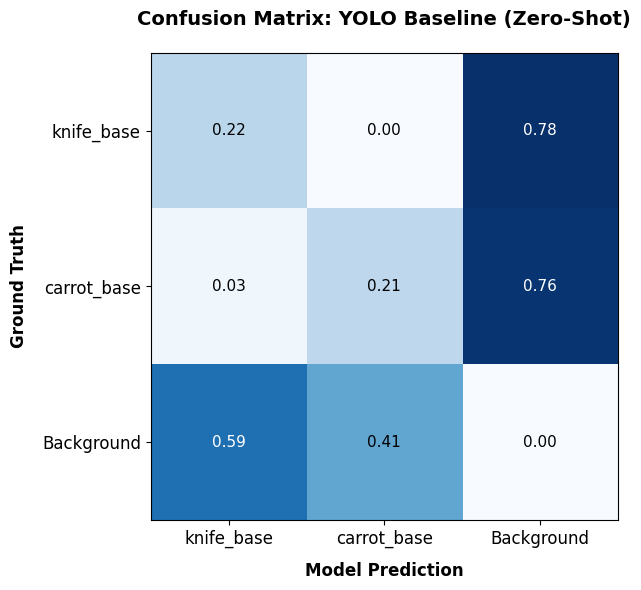

In [7]:
print("Calculating matrix for Baseline Model (Zero-Shot)...")

# Map COCO IDs to simple indices for the 3x3 matrix
map_base = {43: 0, 51: 1} 
names_base = ['knife_base', 'carrot_base', 'Background']

generate_confusion_matrix(
    model=model_base,
    dir_img=TEMP_IMAGES,
    dir_lbl=TEMP_LABELS,
    class_map=map_base,
    class_names=names_base,
    title="Confusion Matrix: YOLO Baseline (Zero-Shot)"
)